# Leuphana Universität Lüneburg - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Leuphana Universität Lüneburg' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02w2y2t16' -- 'Leuphana Universität Lüneburg'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Leuphana Universität Lüneburg,"Leuphana University, Faculty of Sustainability...",https://openalex.org/W4399495617
1,not assigned,Leuphana Universität Lüneburg,"Leuphana University Lüneburg, Institute of Man...",https://openalex.org/W4395032060
2,not assigned,Leuphana Universität Lüneburg,Department of Health Psychology and Applied Bi...,https://openalex.org/W4392707043
3,not assigned,Leuphana Universität Lüneburg,"Institute of Management, Accounting and Financ...",https://openalex.org/W4403924135
4,not assigned,Leuphana Universität Lüneburg,"Social-Ecological Systems Institute, Leuphana ...",https://openalex.org/W4403872091


In [411]:
MAPPING_DICT = {
    'DFG-Kollegforschergruppe Medienkulturen der Computersimulation (mecs)': ['media cultures', 'mecs,'],
    'Fakultät Bildung': ['sport', 'psychology', 'theologie', 'education', 'english', 'dida(c|k)ti(c|k)', 'fakultät bildung', 'institut für psychologie',
                         'bildungswissenschaft', 'social work', 'sozialarbeit', 'digital teaching', 'schulpädagogik', 'mathematics', 'social sciences'
                        ],
    'Fakultät Kulturwissenschaften': ['(isco)', 'sociology', 'philosophy', 'kulturorganisation', 'culture and aesthetics', 'geschichtswissenschaft',
                                      'ästhetik', 'kunstwissenschaft', 'cultural management', 'icam,'
                                     ],
    'Fakultät Management und Technologie': ['management (&|and|und|&amp;) organi(z|s)ation', 
                                            'process', 'production', 'information', 
                                            '(sesi)', 'accounting', 'social‐ecological', 'Social(‐|-)Ecological',
                                            'explainability', 'produktionstechnik', 'performance', 'product technology',
                                            'banking', 'innovation', 'business and economics', '(faculty|school) of management (and|&amp;|&) technology',
                                            'department of management', 'wirtschaftsinformatik', 'machine learning', 'digital transformation',
                                            'administration', 'control and drive systems'
                                           ],
    'Fakultät Nachhaltigkeit': ['sustainability', 'ecolog(y|ical)', 'chemistry', 'nachhaltigkeit', 'chemie', 'environmental communication',
                                'energy law', 'ethics', 'sustainable development', 'umweltrecht', 'nachhaltige entwicklung',
                                'insugo,', 'isec,', 'energy economics'
                               ],
    'Fakultät Staatswissenschaften': ['politikwissenschaft', 'institute (of|for) economics', 'political science', 'volkswirtschaft(s)?lehre',
                                      'political culture', 'public affairs'
                                     ],
    #'Forschungszentrum Futures of Ecosystem Services (FuturES)': [],
    'Methodenzentrum': ['cent(er|re) (of|for) methods'],
    #'Research Center for Entrepreneurship (RCE)': [],
    #'Zentraleinrichtung Sprachenzentrum': [],
    'Zentrum Digitale Kulturen (CDC)': ['Digital Cultures'],
    'Zentrum für Angewandte Gesundheitswissenschaften (ZAG)': ['health', 'gesundheitswissenschaften'],
    'Zentrum für Demokratieforschung (ZDEMO)': ['demokratieforschung', 'democracy'],
    #'Zentrum für Empirische Forschung zu Sprache und Bildung (ERLE)': [],
    'Zukunftszentrum Lehrerbildung': ['lehr(er|kräfte)bildung', 'competencies for digitally-enhanced']
}

In [412]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [413]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [414]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Nachhaltigkeit,Leuphana Universität Lüneburg,"Leuphana University, Faculty of Sustainability...",https://openalex.org/W4399495617
1,Fakultät Management und Technologie,Leuphana Universität Lüneburg,"Leuphana University Lüneburg, Institute of Man...",https://openalex.org/W4395032060
2,Fakultät Bildung,Leuphana Universität Lüneburg,Department of Health Psychology and Applied Bi...,https://openalex.org/W4392707043
3,Fakultät Management und Technologie,Leuphana Universität Lüneburg,"Institute of Management, Accounting and Financ...",https://openalex.org/W4403924135
4,Fakultät Management und Technologie,Leuphana Universität Lüneburg,"Social-Ecological Systems Institute, Leuphana ...",https://openalex.org/W4403872091
...,...,...,...,...
3175,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3120880167
3176,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3164247474
3177,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3081824859
3178,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3154334308


In [415]:
df_with_inst[(df_with_inst.inst_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('leuphana', case=False, regex=False)].raw_affiliation_string.unique()

array(['Leuphana University , Luneburg , Germany',
       'Leuphana University Lüneburg, Universitätsallee 1, 21335 Lüneburg, Germany',
       'Leuphana University Lueneburg, Germany',
       'Leuphana University Lueneburg, GERMANY',
       'Leuphana University Lueneburg,  GERMANY',
       'Leuphana Universität Lueneburg, Universitätsallee 1, 21335, Lüneburg, Germany',
       'Leuphana Universität Lüneburg, Lüneburg, Germany',
       'Yunus Centre for Social Business and Values, Leuphana University Lüneburg, Germany',
       'Leuphana University Lüneburg  Lüneburg Germany',
       'Leuphana University,Lueneburg,Germany',
       'State University, Leuphana University of Lneburg, Lneburg, Germany',
       'State University, Leuphana University of Lüneburg, Lüneburg, Germany',
       'Leuphana University, Universitaetsallee 1, 21335, Lueneburg, Germany',
       'Leuphana Universität, Lüneburg',
       'Leuphana University of Lueneburg, Germany',
       'Leuphana University of Luneburg, Lü

In [416]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,DFG-Kollegforschergruppe Medienkulturen der Co...,8
1,Fakultät Bildung,419
2,Fakultät Kulturwissenschaften,44
3,Fakultät Management und Technologie,702
4,Fakultät Nachhaltigkeit,707
5,Fakultät Staatswissenschaften,72
6,Methodenzentrum,7
7,Zentrum Digitale Kulturen (CDC),3
8,Zentrum für Angewandte Gesundheitswissenschaft...,118
9,Zentrum für Demokratieforschung (ZDEMO),24


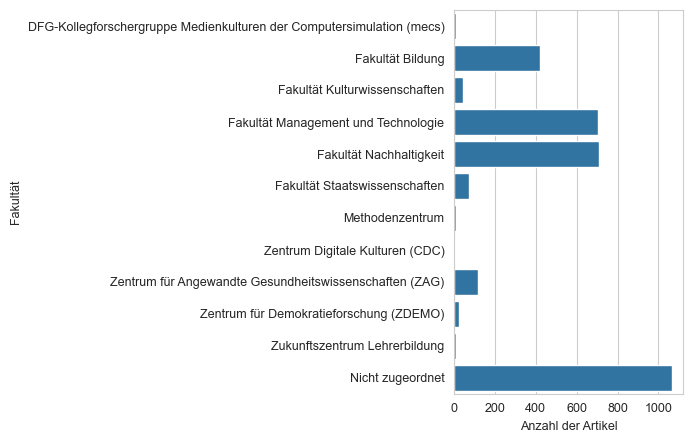

In [417]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [418]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6644654088050315